In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split , StratifiedKFold , cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
plt.style.use("default")
plt.rcParams["figure.figsize"] = (7 , 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.20
plt.rcParams["axes.titlesize"] = 17
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 10
X , y = make_moons(n_samples = 300 , noise = 0.22 , random_state = 42)
model_simple = LogisticRegression(max_iter = 2000)
model_flexible = Pipeline([
    ("poly" , PolynomialFeatures(degree = 3 , include_bias = False)) ,
    ("logreg" , LogisticRegression(max_iter = 2000))
])

In [3]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.25 ,
                                                       stratify = y , random_state = 42)
_ = model_simple.fit(X_train , y_train)
_ = model_flexible.fit(X_train , y_train)
single_simple = accuracy_score(y_test , model_simple.predict(X_test))
single_flexible = accuracy_score(y_test , model_flexible.predict(X_test))
cv = StratifiedKFold(n_splits = 5 , shuffle = True , random_state = 42)
scores_simple = cross_val_score(model_simple , X , y , cv = cv , scoring = "accuracy")
scores_flexible = cross_val_score(model_flexible , X , y , cv = cv , scoring = "accuracy")
simple_mean = scores_simple.mean()
simple_std = scores_simple.std()
flex_mean = scores_flexible.mean()
flex_std = scores_flexible.std()

In [4]:
print("Single split test accuracy")
print(f"  Simple model : {single_simple:.3f}")
print(f"  Flexible model : {single_flexible:.3f}")

print("\n5-fold cross-validation accuracy")
print(f"  Simple model : {np.round(scores_simple , 3)}")
print(f"  Mean +/- Std : {simple_mean:.3f} +/- {simple_std:.3f}")

print(f"\n  Flexible model : {np.round(scores_flexible, 3)}")
print(f"  Mean +/- Std : {flex_mean:.3f} +/- {flex_std:.3f}")

print("\n" , " " * 23 , "Takeaway")
print("=" * 58)
print("Cross-validation is more reliable than trusting one split.")
print("It evaluates models across multiple folds, not just one train/test result.")
print("The flexible model performs better on average here.")
print("That makes the comparison more stable and more trustworthy.")

Single split test accuracy
  Simple model : 0.827
  Flexible model : 0.880

5-fold cross-validation accuracy
  Simple model : [0.733 0.9   0.883 0.883 0.9  ]
  Mean +/- Std : 0.860 +/- 0.064

  Flexible model : [0.8   0.933 0.95  0.95  0.933]
  Mean +/- Std : 0.913 +/- 0.057

                         Takeaway
Cross-validation is more reliable than trusting one split.
It evaluates models across multiple folds, not just one train/test result.
The flexible model performs better on average here.
That makes the comparison more stable and more trustworthy.


Text(0.5, 0, 'Fold')

Text(0, 0.5, 'Accuracy')

(0.72, 0.97)

Text(0.5, 1.0, 'K-Fold Cross-Validation Performance')

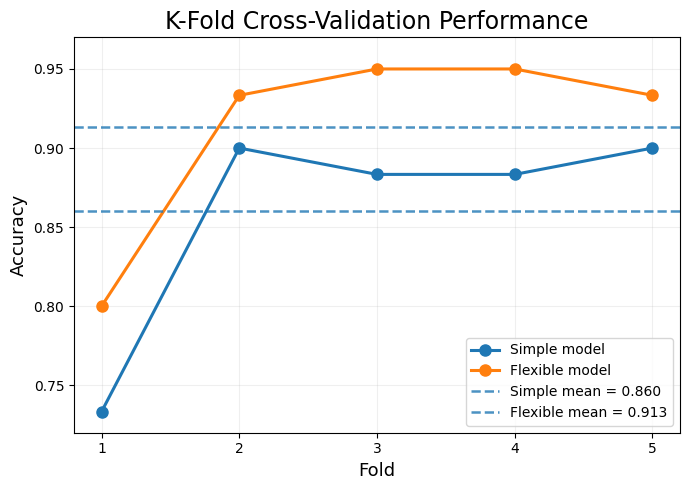

In [5]:
folds = np.arange(1 , len(scores_simple) + 1)
fig , ax = plt.subplots()
ax.plot(folds , scores_simple , marker = "o" , linewidth = 2.2 ,
        markersize = 8 , label = "Simple model")
ax.plot(folds , scores_flexible , marker = "o" , linewidth = 2.2 ,
        markersize = 8 , label = "Flexible model")
ax.axhline(simple_mean , linestyle = "--" , linewidth = 1.8 , alpha = 0.8 ,
           label = f"Simple mean = {simple_mean:.3f}")
ax.axhline(flex_mean , linestyle = "--" , linewidth = 1.8 , alpha = 0.8 ,
           label = f"Flexible mean = {flex_mean:.3f}")
ax.set_xticks(folds)
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.72 , 0.97)
ax.set_title("K-Fold Cross-Validation Performance")
ax.legend(loc = "best")
fig.tight_layout()
plt.show()

[Text(0, 0, 'Simple'), Text(1, 0, 'Flexible')]

(0.75, 1.0)

Text(0, 0.5, 'Accuracy')

Text(0.5, 1.0, 'Single Split vs Cross-Validation Estimate')

Text(-0.175, 0.8316666666666667, '0.827')

Text(0.825, 0.885, '0.880')

Text(0.175, 0.865, '0.860')

Text(1.175, 0.9183333333333334, '0.913')

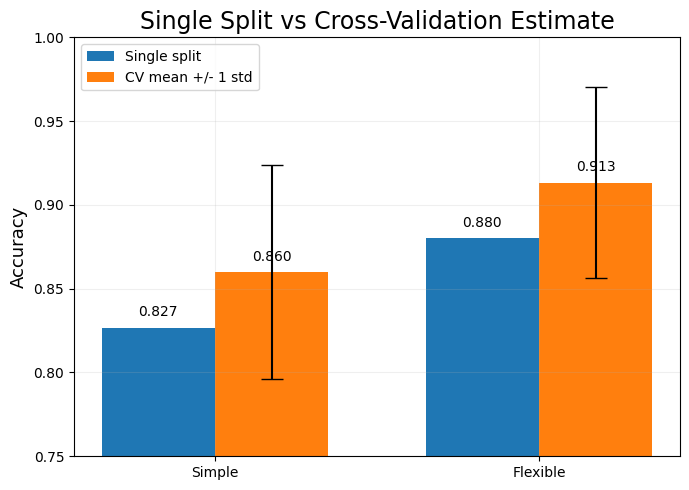

In [6]:
labels = ["Simple" , "Flexible"]
single_scores = [single_simple , single_flexible]
cv_means = [simple_mean , flex_mean]
cv_stds = [simple_std , flex_std]
x = np.arange(len(labels))
width = 0.35
fig , ax = plt.subplots()
bars1 = ax.bar(x - width / 2 , single_scores , width , label = "Single split")
bars2 = ax.bar(x + width / 2 , cv_means , width , yerr = cv_stds ,
               capsize = 8 , label = "CV mean +/- 1 std")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.75 , 1.00)
ax.set_ylabel("Accuracy")
ax.set_title("Single Split vs Cross-Validation Estimate")
ax.legend()
for bars in [bars1 , bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2 , h + 0.005 , f"{h:.3f}" ,
                ha = "center" , va = "bottom" , fontsize = 10)
fig.tight_layout()
plt.show()